<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
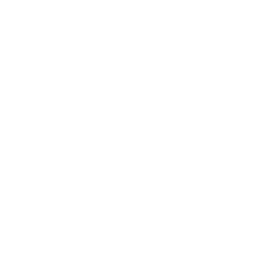
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">PROC DQMATCH — Σύνδεση Εγγραφών Πελατών σε Συστήματα CRM</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Ενοποίηση ταυτοτήτων πελατών μετά τη συγχώνευση δύο πλατφορμών CRM &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για τα Στελέχη

Όταν δύο εταιρείες συγχωνεύονται, οι βάσεις δεδομένων πελατών τους επικαλύπτονται: το ίδιο άτομο μπορεί να εμφανίζεται πολλές φορές με ελαφρώς διαφορετικό όνομα, με αναδιαμορφωμένο αριθμό τηλεφώνου ή με νέα διεύθυνση email. Η σύνδεση αποκλειστικά βάσει ακριβούς email παραλείπει σιωπηλά τα περισσότερα από αυτά τα διπλότυπα και γεμίζει την ενοποιημένη πλατφόρμα με φαντάσματα λογαριασμών.

Αυτό το notebook χρησιμοποιεί το **PROC DQMATCH** για να επιλύσει τις ταυτότητες πελατών ανάμεσα σε ένα παλαιό (legacy) και ένα εξαγορασθέν CRM. Από **25 εγγραφές προέλευσης** εντοπίζει **16 διακριτούς πελάτες**, συμπτύσσοντας **8 από αυτές τις ταυτότητες** από διπλότυπες γραμμές που η σύνδεση βάσει ακριβούς email δεν μπορούσε να συνδέσει. Κάθε συνδεδεμένη ταυτότητα παρακάτω είναι ανιχνεύσιμη ως προς τις γραμμές προέλευσής της, ώστε η συγχώνευση να είναι ελέγξιμη αντί για εικαζόμενη.

## Δεδομένα

Ένας ενιαίος συνδυασμένος πίνακας περιέχει **25 εγγραφές** από τα δύο συστήματα (**12 LEGACY**, **13 ACQUIRED**). Οι επικαλυπτόμενες γραμμές δημιουργήθηκαν σκόπιμα με ρεαλιστική διακύμανση — `Robert Chen` έναντι `Bob Chen` έναντι `Mr. Robert Chen`, `617-555-0142` έναντι `(617) 555-0142` έναντι `6175550142`, προσωπικοί έναντι εταιρικών τομέων email — ώστε η αντιστοίχιση να έχει κάτι πραγματικό να επιλύσει. Οι εγγραφές των οποίων τα email καταλήγουν σε `@newco.com` είναι γνήσια νέοι εξαγορασθέντες πελάτες χωρίς αντίστοιχο στο παλαιό σύστημα.

---

In [1]:
/* Combine the two merged CRM systems into one table.
   After a corporate merger, the same real customer often appears
   in BOTH systems - and even multiple times within one system -
   with small variations in name, email, phone, and address.
   The goal is to resolve these duplicates into one identity each. */
ΔΕΔΟΜΕΝΑ crm_combined;
    LENGTH source $8 cust_id $10 full_name $40 email $45
           phone $16 address $40;
    INFILE DATALINES dlm='|' dsd truncover;
    ΕΙΣΟΔΟΣ source $ cust_id $ full_name $ email $ phone $ address $;
DATALINES;
LEGACY|LGC0001|Robert Chen|robert.chen@gmail.com|617-555-0142|45 Oak Avenue
ACQUIRED|ACQ0001|Bob Chen|rchen@company.com|(617) 555-0142|45 Oak Ave
ACQUIRED|ACQ0002|Mr. Robert Chen|robert.chen@gmail.com|6175550142|45 Oak Avenue Apt 2
LEGACY|LGC0002|Jennifer Williams|jwilliams@yahoo.com|212-555-0177|88 Pine Street
ACQUIRED|ACQ0003|Jenny Williams|jenny.williams@yahoo.com|212-555-0177|88 Pine St
LEGACY|LGC0003|Michael Rodriguez|mrodriguez@outlook.com|305-555-0188|12 Beach Blvd
ACQUIRED|ACQ0004|Mike Rodriguez|mike.r@company.com|(305) 555-0188|12 Beach Boulevard
LEGACY|LGC0004|Sarah Johnson|sjohnson@gmail.com|415-555-0199|7 Hill Road
LEGACY|LGC0005|David Patel|dpatel@hotmail.com|312-555-0211|300 Lake Drive
ACQUIRED|ACQ0005|Dave Patel|david.patel@company.com|312-555-0211|300 Lake Dr
LEGACY|LGC0006|Emily Thompson|ethompson@icloud.com|617-555-0233|9 Maple Court
LEGACY|LGC0007|Kevin Nguyen|knguyen@gmail.com|214-555-0244|55 Cedar Lane
ACQUIRED|ACQ0006|Kevin Nguyen|knguyen@gmail.com|2145550244|55 Cedar Ln
LEGACY|LGC0008|Amanda Smith|asmith@yahoo.com|206-555-0255|18 River Way
ACQUIRED|ACQ0007|Amanda M. Smith|amanda.smith@company.com|(206) 555-0255|18 River Way
LEGACY|LGC0009|Christopher Lee|clee@outlook.com|503-555-0266|22 Forest Ave
LEGACY|LGC0010|Nicole Davis|ndavis@gmail.com|602-555-0277|14 Sunset Blvd
ACQUIRED|ACQ0008|Nikki Davis|nicole.davis@company.com|602-555-0277|14 Sunset Boulevard
ACQUIRED|ACQ0009|Brian Murphy|bmurphy@newco.com|720-555-0301|1 Mountain VIEW
ACQUIRED|ACQ0010|Laura Martinez|lmartinez@newco.com|480-555-0312|6 Desert Road
ACQUIRED|ACQ0011|Jason Brown|jbrown@newco.com|702-555-0323|33 Canyon St
ACQUIRED|ACQ0012|Megan Wilson|mwilson@newco.com|808-555-0334|99 Palm Drive
LEGACY|LGC0011|Ashley Taylor|ataylor@gmail.com|404-555-0345|71 Peach TREE Rd
ACQUIRED|ACQ0013|Ashley Taylor|ataylor@gmail.com|(404) 555-0345|71 Peachtree Road
LEGACY|LGC0012|Ryan Anderson|randerson@yahoo.com|615-555-0356|40 Music Row
;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=crm_combined (obs=7) noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ source='Σύστημα' cust_id='Κωδικός Πελάτη' full_name='Ονοματεπώνυμο' email='Email' phone='Τηλέφωνο' address='Διεύθυνση';
    TITLE 'Δείγμα Συνδυασμένων Εγγραφών CRM μετά τη Συγχώνευση';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SQL;
    ΕΠΙΛΟΓΗ count(*) AS total_records FROM crm_combined;
    ΕΠΙΛΟΓΗ source, count(*) AS n FROM crm_combined GROUP ΚΑΤΑ source;
QUIT;


                                  Δείγμα Συνδυασμένων Εγγραφών CRM μετά τη Συγχώνευση                                   

       Σύστημα               Κωδικός Πελάτη               Ονοματεπώνυμο                     Email          Τηλέφωνο            Διεύθυνση
LEGACY          LGC0001                      Robert Chen                 robert.chen@gmail.com     617-555-0142      45 Oak Avenue
ACQUIRED        ACQ0001                      Bob Chen                    rchen@company.com         (617) 555-0142    45 Oak Ave
ACQUIRED        ACQ0002                      Mr. Robert Chen             robert.chen@gmail.com     6175550142        45 Oak Avenue Apt 2
LEGACY          LGC0002                      Jennifer Williams           jwilliams@yahoo.com       212-555-0177      88 Pine Street
ACQUIRED        ACQ0003                      Jenny Williams              jenny.williams@yahoo.com  212-555-0177      88 Pine St
LEGACY          LGC0003                      Michael Rodriguez           mrodriguez@o


NOTE: DATA crm_combined

NOTE: Processing inline DATALINES (25 lines)

NOTE: Read 25 rows from DATALINES.
NOTE: Wrote crm_combined (25 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=crm_combined

NOTE: PROC PRINT completed: 7 observations printed, 6 variables
NOTE: PROC SQL 

NOTE: PROC SQL statement used.


### Γιατί η ακριβής αντιστοίχιση δεν αρκεί

Η αφελής προσέγγιση συνδέει τα δύο συστήματα εκεί όπου οι συμβολοσειρές email είναι πανομοιότυπες. Είναι γρήγορη, αλλά εντοπίζει μόνο τους πελάτες που διατήρησαν ακριβώς την ίδια διεύθυνση κατά τη μετάπτωση — και κατά την ενοποίηση ενός CRM πολλοί δεν το κάνουν.

In [2]:
/* Baseline a data team might try first: exact email join.
   It only links records whose email strings match character for
   character, so it misses every customer whose email was
   reformatted or changed during the migration. */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    CREATE TABLE email_exact AS
    ΕΠΙΛΟΓΗ a.cust_id AS legacy_id, b.cust_id AS acquired_id,
           a.full_name, a.email
    FROM crm_combined a
    INNER JOIN crm_combined b
        ON lowcase(a.email) = lowcase(b.email)
        AND a.source = 'LEGACY' AND b.source = 'ACQUIRED';

    ΕΠΙΛΟΓΗ count(*) AS exact_email_links FROM email_exact;
QUIT;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=email_exact noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ legacy_id='Κωδικός Παλαιού' acquired_id='Κωδικός Εξαγορασθέντος' full_name='Ονοματεπώνυμο' email='Email';
    TITLE 'Διασυστημικές Συνδέσεις μόνο με Ακριβή Αντιστοίχιση Email';
ΕΚΤΕΛΕΣΗ;


                                  Δείγμα Συνδυασμένων Εγγραφών CRM μετά τη Συγχώνευση                                   

exact_email_links
-----------------
                3
                               Διασυστημικές Συνδέσεις μόνο με Ακριβή Αντιστοίχιση Email                                

              Κωδικός Παλαιού                       Κωδικός Εξαγορασθέντος               Ονοματεπώνυμο                  Email
LGC0001                        ACQ0002                                      Robert Chen                 robert.chen@gmail.com
LGC0007                        ACQ0006                                      Kevin Nguyen                knguyen@gmail.com
LGC0011                        ACQ0013                                      Ashley Taylor               ataylor@gmail.com




NOTE: PROC SQL 

NOTE: Table email_exact created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=email_exact

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


Η αντιστοίχιση βάσει ακριβούς email συνδέει **μόνο 3 από τα διασυστημικά διπλότυπα** — τους Robert Chen, Kevin Nguyen και Ashley Taylor, καθένας από τους οποίους έτυχε να διατηρήσει πανομοιότυπη διεύθυνση. Πελάτες όπως η εξαγορασθείσα εγγραφή του *Bob Chen* (`rchen@company.com`) και ο *Mike Rodriguez* (τώρα `mike.r@company.com`) είναι αόρατοι σε αυτήν, παρόλο που οι αριθμοί τηλεφώνου και τα ονόματά τους τους προσδιορίζουν σαφώς. Μια στρατηγική σύνδεσης που βασίζεται μόνο στο email θα άφηνε αυτούς τους πελάτες διπλομετρημένους στην ενοποιημένη πλατφόρμα.

---

### Σύνδεση πολλαπλών σημάτων με το PROC DQMATCH

Το DQMATCH παράγει ασαφείς **κωδικούς αντιστοίχισης** ανά πεδίο και ομαδοποιεί τις εγγραφές των οποίων οι κωδικοί συμφωνούν. Χρησιμοποιώντας δύο ομάδες συνθηκών — *όνομα και τηλέφωνο* Ή *email* — ένα μεμονωμένο τροποποιημένο πεδίο δεν μπορεί να διασπάσει έναν πραγματικό πελάτη, ενώ η συμφωνία σε οποιοδήποτε από τα δύο ισχυρά σήματα αρκεί για τη σύνδεση.

In [3]:
/* PROC DQMATCH resolves identities using fuzzy match codes.
   Two CONDITION groups give OR logic across signals:
     Condition 1  name AND phone agree  (survives email changes)
     Condition 2  email agrees          (survives name/phone changes)
   A record joins a cluster if EITHER condition is satisfied, so a
   single changed field never splits a true customer apart. */
ΔΙΑΔΙΚΑΣΙΑ dqmatch ΔΕΔΟΜΕΝΑ=crm_combined out=crm_linked
             matchcode=match_code CLUSTER=customer_id locale='ENUSA';
    criteria ΜΕΤΑΒΛΗΤΗ=full_name matchdef='Name'  sensitivity=80 condition=1;
    criteria ΜΕΤΑΒΛΗΤΗ=phone     matchdef='Phone' sensitivity=85 condition=1;
    criteria ΜΕΤΑΒΛΗΤΗ=email     matchdef='Email' sensitivity=85 condition=2;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=crm_linked noobs ΕΤΙΚΕΤΑ;
    ΜΕΤΑΒΛΗΤΗ customer_id source cust_id full_name email phone;
    ΕΤΙΚΕΤΑ customer_id='Ταυτότητα Πελάτη' source='Σύστημα' cust_id='Κωδικός Πελάτη' full_name='Ονοματεπώνυμο' email='Email' phone='Τηλέφωνο';
    TITLE 'Εγγραφές Ομαδοποιημένες κατά Επιλυμένη Ταυτότητα Πελάτη';
ΕΚΤΕΛΕΣΗ;


                               Διασυστημικές Συνδέσεις μόνο με Ακριβή Αντιστοίχιση Email                                

                                Εγγραφές Ομαδοποιημένες κατά Επιλυμένη Ταυτότητα Πελάτη                                 

               Ταυτότητα Πελάτη         Σύστημα               Κωδικός Πελάτη               Ονοματεπώνυμο                     Email          Τηλέφωνο
                              1  LEGACY          LGC0001                      Robert Chen                 robert.chen@gmail.com     617-555-0142
                              1  ACQUIRED        ACQ0001                      Bob Chen                    rchen@company.com         (617) 555-0142
                              1  ACQUIRED        ACQ0002                      Mr. Robert Chen             robert.chen@gmail.com     6175550142
                              2  LEGACY          LGC0002                      Jennifer Williams           jwilliams@yahoo.com       212-555-0177
                           


NOTE: PROCEDURE DQMATCH
NOTE: PROC DQMATCH using LOCALE=ENUSA.
NOTE: Output dataset crm_linked has 25 observations and 8 variables. 16 clusters identified.
NOTE: PROC DQMATCH statement used.
NOTE: PROC PRINT data=crm_linked

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


Η στήλη συστάδας `customer_id` αφηγείται την ιστορία απευθείας. Η **Συστάδα 1** ενοποιεί και τις τρεις γραμμές του Robert Chen παρόλο που μία φέρει εταιρικό email· οι **συστάδες 2, 3, 5, 7, 8, 10 και 15** συνδυάζουν καθεμία μια παλαιά εγγραφή με το εξαγορασθέν δίδυμό της, παρά τις διαφορές στη γραφή ονομάτων, στις μορφές τηλεφώνου και στις αλλαγές τομέα email. Οι έξι εγγραφές `@newco.com` παραμένουν μεμονωμένες — ορθώς, διότι είναι εντελώς νέοι πελάτες.

---

### Πόσο ενοποίησε η επίλυση ταυτοτήτων;

                                Εγγραφές Ομαδοποιημένες κατά Επιλυμένη Ταυτότητα Πελάτη                                 

resolved_identities  source_records  merged_identities  singletons
-------------------  --------------  -----------------  ----------
                 16            25.0                  8           8
cross_system_links
------------------
                 8
                                   Εγγραφές Προέλευσης ανά Επιλυμένη Ταυτότητα Πελάτη                                   

                                                   The FREQ Procedure

Πλήθος Εγγραφών                  Frequency    Percent
------------------------------------------------------
1                                        8     50.00
2                                        7     43.75
3                                        1      6.25



NOTE: PROC SQL 

NOTE: Table cluster_sizes created.
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_record_count.spec.json
NOTE: PROC FREQ statement used.


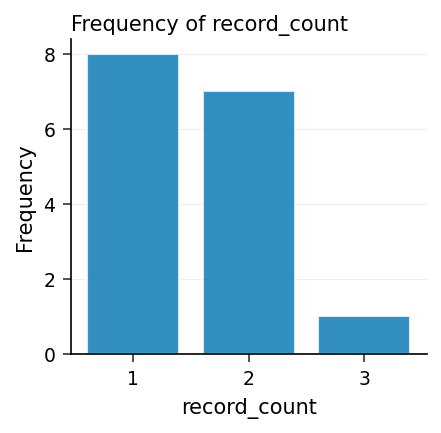

In [4]:
/* Summarize the resolution: how many source records collapsed
   into each customer identity, and how many identities merged. */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    CREATE TABLE cluster_sizes AS
    ΕΠΙΛΟΓΗ customer_id, count(*) AS record_count
    FROM crm_linked
    GROUP ΚΑΤΑ customer_id;

    ΕΠΙΛΟΓΗ count(*) AS resolved_identities,
           sum(record_count) AS source_records,
           sum(CASE ΟΤΑΝ record_count > 1 ΤΟΤΕ 1 ΑΛΛΙΩΣ 0 ΤΕΛΟΣ)
               AS merged_identities,
           sum(CASE ΟΤΑΝ record_count = 1 ΤΟΤΕ 1 ΑΛΛΙΩΣ 0 ΤΕΛΟΣ)
               AS singletons
    FROM cluster_sizes;

    /* Of the merged identities, how many span BOTH systems? */
    ΕΠΙΛΟΓΗ count(*) AS cross_system_links
    FROM (ΕΠΙΛΟΓΗ customer_id FROM crm_linked
          GROUP ΚΑΤΑ customer_id
          HAVING count(DISTINCT source) > 1);
QUIT;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=cluster_sizes;
    TABLES record_count / nocum;
    ΕΤΙΚΕΤΑ record_count='Πλήθος Εγγραφών';
    TITLE 'Εγγραφές Προέλευσης ανά Επιλυμένη Ταυτότητα Πελάτη';
ΕΚΤΕΛΕΣΗ;


Το DQMATCH επέλυσε τις **25 εγγραφές προέλευσης σε 16 ταυτότητες πελατών**. Οκτώ από αυτές τις ταυτότητες είναι **συγχωνευμένες συστάδες** (δύο ή τρεις γραμμές η καθεμία) και οκτώ είναι **μεμονωμένες**. Κρίσιμο είναι ότι **και οι 8 συγχωνευμένες ταυτότητες εκτείνονται και στα δύο συστήματα προέλευσης** — κάθε ενοποίηση είναι μια πραγματική διασυστημική σύνδεση CRM, όχι ένα τεχνούργημα εντός του ίδιου συστήματος. Η κατανομή μεγεθών είναι επτά ταυτότητες των 2 εγγραφών (43.75%) και μία ταυτότητα των 3 εγγραφών (6.25%)· το υπόλοιπο 50% είναι εγγραφές μίας μόνο πηγής. Σε σύγκριση με τις **3 συνδέσεις που βρήκε το ακριβές email**, το DQMATCH **αύξησε τις διασυστημικές αντιστοιχίσεις σε 8** — υπερδιπλασιάζοντάς τες αξιοποιώντας τη συμφωνία ονόματος και τηλεφώνου.

---

### Παραγωγή της χρυσής εγγραφής

Με τις ταυτότητες επιλυμένες, επιλέγεται μία επιζώσα γραμμή ανά πελάτη για την ενοποιημένη πλατφόρμα, επισημασμένη με το πλήθος των γραμμών προέλευσης που απορρόφησε.

In [5]:
/* Build the golden record: one surviving row per customer.
   Survivorship rule: keep the LEGACY values when the customer
   exists in the legacy system (the established system of record);
   otherwise fall back to the acquired values. merged_from counts
   how many source records each identity absorbed. */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    CREATE TABLE golden_records AS
    ΕΠΙΛΟΓΗ g.customer_id,
           COALESCE(leg.cust_id,   acq.cust_id)   AS golden_cust_id,
           COALESCE(leg.full_name, acq.full_name) AS full_name,
           COALESCE(leg.email,     acq.email)     AS primary_email,
           g.merged_from
    FROM (ΕΠΙΛΟΓΗ customer_id, count(*) AS merged_from
          FROM crm_linked GROUP ΚΑΤΑ customer_id) g
    LEFT JOIN (ΕΠΙΛΟΓΗ customer_id, MIN(cust_id) AS cust_id,
                      MIN(full_name) AS full_name, MIN(email) AS email
               FROM crm_linked ΟΠΟΥ source='LEGACY'
               GROUP ΚΑΤΑ customer_id) leg
        ON g.customer_id = leg.customer_id
    LEFT JOIN (ΕΠΙΛΟΓΗ customer_id, MIN(cust_id) AS cust_id,
                      MIN(full_name) AS full_name, MIN(email) AS email
               FROM crm_linked ΟΠΟΥ source='ACQUIRED'
               GROUP ΚΑΤΑ customer_id) acq
        ON g.customer_id = acq.customer_id
    ORDER ΚΑΤΑ g.merged_from DESC, g.customer_id;
QUIT;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=golden_records (obs=10) noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ customer_id='Ταυτότητα Πελάτη' golden_cust_id='Χρυσός Κωδικός Πελάτη' full_name='Ονοματεπώνυμο' primary_email='Κύριο Email' merged_from='Συγχωνευμένες Εγγραφές';
    TITLE 'Χρυσές Εγγραφές για το Ενοποιημένο CRM (κατά πλήθος συγχωνεύσεων)';
ΕΚΤΕΛΕΣΗ;


                                   Εγγραφές Προέλευσης ανά Επιλυμένη Ταυτότητα Πελάτη                                   

                           Χρυσές Εγγραφές για το Ενοποιημένο CRM (κατά πλήθος συγχωνεύσεων)                            

               Ταυτότητα Πελάτη                     Χρυσός Κωδικός Πελάτη               Ονοματεπώνυμο             Κύριο Email                       Συγχωνευμένες Εγγραφές
                              1  LGC0001                                   Robert Chen                 robert.chen@gmail.com                                             3
                              2  LGC0002                                   Jennifer Williams           jwilliams@yahoo.com                                               2
                              3  LGC0003                                   Michael Rodriguez           mrodriguez@outlook.com                                            2
                              5  LGC0005                                


NOTE: PROC SQL 

NOTE: Table golden_records created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=golden_records

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


Ο χρυσός πίνακας περιέχει **16 γραμμές — μία ανά πραγματικό πελάτη** — με τη στήλη `merged_from` να δείχνει πόσες αρχικές εγγραφές απορρόφησε καθεμία (3 για τον Robert Chen, 2 για καθεμία από τις υπόλοιπες επτά συνδεδεμένες ταυτότητες, 1 για τις υπόλοιπες). Η φόρτωση αυτών στο ενοποιημένο CRM αποφεύγει τους φανταστικούς διπλότυπους λογαριασμούς που θα είχε δημιουργήσει η αντιστοίχιση βάσει ακριβούς email, και επειδή κάθε χρυσή εγγραφή παραπέμπει πίσω στη συστάδα της, η ενοποίηση παραμένει πλήρως ελέγξιμη.

**Συμπέρασμα:** για δεδομένα πελατών μετά από συγχώνευση, η ασαφής σύνδεση πολλαπλών σημάτων με το PROC DQMATCH ανακτά διπλότυπα που οι ακριβείς συνδέσεις χάνουν — εδώ διπλασιάζοντας τις διασυστημικές αντιστοιχίσεις και μειώνοντας τις 25 εγγραφές σε 16 καθαρές ταυτότητες.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>